In [48]:
!pip install pycountry

import pandas as pd
import numpy as np
import requests
import pycountry
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [49]:
def get_wb_data(indicator: str, col_name: str) -> pd.DataFrame:
    url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator}"
    params = {
        "format": "json",
        "per_page": 20000
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()

    json_data = response.json()

    # check API response structure
    if not isinstance(json_data, list) or len(json_data) < 2 or json_data[1] is None:
        raise ValueError(f"No data returned for indicator: {indicator}")

    data = json_data[1]
    df = pd.json_normalize(data)

    # keep only needed columns
    df = df[["country.value", "date", "value"]].copy()
    df.columns = ["Country", "Year", col_name]

    # convert year and values
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df[col_name] = pd.to_numeric(df[col_name], errors="coerce")

    # drop rows with missing country/year
    df = df.dropna(subset=["Country", "Year"])

    # make year integer
    df["Year"] = df["Year"].astype(int)

    return df


# fetch datasets
pm25 = get_wb_data("EN.ATM.PM25.MC.M3", "PM25")
life = get_wb_data("SP.DYN.LE00.IN", "LifeExp")
gdp = get_wb_data("NY.GDP.PCAP.PP.CD", "GDP")
health = get_wb_data("SH.XPD.CHEX.PP.CD", "HealthExp")
pop = get_wb_data("SP.POP.TOTL", "Population")
urban = get_wb_data("SP.URB.TOTL.IN.ZS", "UrbanRate")
industry = get_wb_data("NV.IND.MANF.ZS", "Manufacturing")

In [50]:
# merging datasets
df = pm25.merge(life, on=["Country", "Year"], how="inner")
df = df.merge(gdp, on=["Country", "Year"], how="inner")
df = df.merge(health, on=["Country", "Year"], how="inner")
df = df.merge(pop, on=["Country", "Year"], how="inner")
df = df.merge(urban, on=["Country", "Year"], how="inner")
df = df.merge(industry, on=["Country", "Year"], how="inner")

In [51]:
# view yearly variable nulls
missing_pct = df.groupby("Year").apply(lambda x: x.isna().mean() * 100)
pd.set_option('display.max_rows', None)
print(missing_pct)
pd.reset_option('display.max_rows')

      Country  Year        PM25    LifeExp         GDP   HealthExp  \
Year                                                                 
1960      0.0   0.0  100.000000    1.12782  100.000000  100.000000   
1961      0.0   0.0  100.000000    0.75188  100.000000  100.000000   
1962      0.0   0.0  100.000000    0.75188  100.000000  100.000000   
1963      0.0   0.0  100.000000    1.12782  100.000000  100.000000   
1964      0.0   0.0  100.000000    1.12782  100.000000  100.000000   
1965      0.0   0.0  100.000000    1.12782  100.000000  100.000000   
1966      0.0   0.0  100.000000    0.75188  100.000000  100.000000   
1967      0.0   0.0  100.000000    0.75188  100.000000  100.000000   
1968      0.0   0.0  100.000000    0.75188  100.000000  100.000000   
1969      0.0   0.0  100.000000    0.75188  100.000000  100.000000   
1970      0.0   0.0  100.000000    0.75188  100.000000  100.000000   
1971      0.0   0.0  100.000000    0.75188  100.000000  100.000000   
1972      0.0   0.0 

/tmp/ipykernel_2999/893492893.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_pct = df.groupby("Year").apply(lambda x: x.isna().mean() * 100)


In [52]:
# restrict year from 2000-2020
df = df[(df["Year"].between(2000, 2020))].dropna()

# drop duplicates
df = df.drop_duplicates(subset=["Country", "Year"]).reset_index(drop=True)

# drop index
df = df.drop(columns=["index"], errors="ignore")

# check valid countries
valid_countries = set([c.name for c in pycountry.countries])

# keep only real countries
df = df[df["Country"].isin(valid_countries)].reset_index(drop=True)
df

,Country,Year,PM25,LifeExp,GDP,HealthExp,Population,UrbanRate,Manufacturing
0,Afghanistan,2020,46.087094,61.454,2561.981761,401.163333,39068979.0,25.262210,7.528115
1,Afghanistan,2019,58.330872,62.941,2583.485332,383.164896,37856121.0,25.143726,7.043181
2,Afghanistan,2018,67.227177,62.443,2432.276701,345.587947,36743039.0,24.999165,6.160177
3,Afghanistan,2017,65.862347,62.406,2335.795862,294.796437,35688935.0,24.835282,3.530422
4,Afghanistan,2016,72.765910,62.646,2213.181441,261.566867,34700612.0,24.658835,4.114197
...,...,...,...,...,...,...,...,...,...
3142,Zimbabwe,2014,23.429253,58.106,3903.427977,203.300574,14207359.0,33.162808,12.591320
3143,Zimbabwe,2013,22.598401,56.842,3783.946337,173.586892,14013808.0,32.901934,12.919650
3144,Zimbabwe,2012,23.539528,55.386,3472.485720,156.086614,13817887.0,32.793175,14.043566
3145,Zimbabwe,2011,23.616283,53.911,3047.317089,161.209011,13595424.0,32.756730,9.173223


In [53]:
# positive value check for log-transformation
df = df[(df["PM25"] > 0) & (df["GDP"] > 0) & (df["HealthExp"] > 0) & (df["Population"] > 0)]

In [54]:
# log transformed dataset (skewness/outlier treatment)
df["log_PM25"] = np.log(df["PM25"])
df["log_GDP"] = np.log(df["GDP"])
df["log_HealthExp"] = np.log(df["HealthExp"])
df["log_Population"] = np.log(df["Population"])
df

,Country,Year,PM25,LifeExp,GDP,HealthExp,Population,UrbanRate,Manufacturing,log_PM25,log_GDP,log_HealthExp,log_Population
0,Afghanistan,2020,46.087094,61.454,2561.981761,401.163333,39068979.0,25.262210,7.528115,3.830533,7.848536,5.994369,17.480839
1,Afghanistan,2019,58.330872,62.941,2583.485332,383.164896,37856121.0,25.143726,7.043181,4.066131,7.856895,5.948465,17.449303
2,Afghanistan,2018,67.227177,62.443,2432.276701,345.587947,36743039.0,24.999165,6.160177,4.208078,7.796583,5.845247,17.419459
3,Afghanistan,2017,65.862347,62.406,2335.795862,294.796437,35688935.0,24.835282,3.530422,4.187567,7.756108,5.686285,17.390351
4,Afghanistan,2016,72.765910,62.646,2213.181441,261.566867,34700612.0,24.658835,4.114197,4.287248,7.702186,5.566690,17.362268
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3142,Zimbabwe,2014,23.429253,58.106,3903.427977,203.300574,14207359.0,33.162808,12.591320,3.153985,8.269610,5.314686,16.469271
3143,Zimbabwe,2013,22.598401,56.842,3783.946337,173.586892,14013808.0,32.901934,12.919650,3.117879,8.238523,5.156678,16.455554
3144,Zimbabwe,2012,23.539528,55.386,3472.485720,156.086614,13817887.0,32.793175,14.043566,3.158681,8.152626,5.050411,16.441474
3145,Zimbabwe,2011,23.616283,53.911,3047.317089,161.209011,13595424.0,32.756730,9.173223,3.161936,8.022017,5.082702,16.425244


In [55]:
# sort panel
df = df.sort_values(["Country", "Year"]).reset_index(drop=True)

# create lags
df["log_PM25_lag1"] = df.groupby("Country")["log_PM25"].shift(1)

# drop NaNs
df = df.dropna(subset=["log_PM25_lag1"]).reset_index(drop=True)
df

,Country,Year,PM25,LifeExp,GDP,HealthExp,Population,UrbanRate,Manufacturing,log_PM25,log_GDP,log_HealthExp,log_Population,log_PM25_lag1
0,Afghanistan,2003,64.176231,57.171,966.962032,85.933025,22733049.0,19.160035,16.923866,4.161633,6.874159,4.453568,16.939330,4.165376
1,Afghanistan,2004,63.826609,57.810,971.633503,93.935804,23560654.0,19.399359,17.554006,4.156170,6.878979,4.542612,16.975089,4.161633
2,Afghanistan,2005,63.319026,58.247,1076.087353,105.927706,24404567.0,19.705910,16.598212,4.148186,6.981087,4.662757,17.010281,4.156170
3,Afghanistan,2006,61.514649,58.553,1121.834471,118.405820,25424094.0,20.110453,16.385537,4.119275,7.022721,4.774118,17.051208,4.148186
4,Afghanistan,2007,58.083785,58.956,1286.949843,112.257676,25909852.0,20.590658,17.747310,4.061887,7.160030,4.720797,17.070134,4.119275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2980,Zimbabwe,2014,23.429253,58.106,3903.427977,203.300574,14207359.0,33.162808,12.591320,3.153985,8.269610,5.314686,16.469271,3.117879
2981,Zimbabwe,2015,23.103879,58.989,4045.898647,191.681867,14399013.0,33.561264,11.888401,3.140001,8.305459,5.255837,16.482670,3.153985
2982,Zimbabwe,2016,22.570698,59.760,4275.449351,188.833821,14600294.0,34.079946,11.595754,3.116653,8.360644,5.240867,16.496552,3.140001
2983,Zimbabwe,2017,17.997754,60.263,10756.445442,143.326048,14812482.0,34.701495,14.026987,2.890247,9.283260,4.965122,16.510981,3.116653


In [56]:
# TABLE 1
# cleaned data description
print(df.shape)
print(df.isna().sum())
print(df.describe().round(2))

(2985, 14)
Country           0
Year              0
PM25              0
LifeExp           0
GDP               0
HealthExp         0
Population        0
UrbanRate         0
Manufacturing     0
log_PM25          0
log_GDP           0
log_HealthExp     0
log_Population    0
log_PM25_lag1     0
dtype: int64
          Year     PM25  LifeExp        GDP  HealthExp    Population  \
count  2985.00  2985.00  2985.00    2985.00    2985.00  2.985000e+03   
mean   2010.74    26.53    70.73   18987.04    1276.32  4.011221e+07   
std       5.73    17.33     8.81   21233.90    1574.28  1.470724e+08   
min    2001.00     4.90    31.53     492.84      14.92  9.586000e+03   
25%    2006.00    14.40    65.22    4170.94     191.95  1.997012e+06   
50%    2011.00    21.25    72.36   11250.18     623.73  8.216724e+06   
75%    2016.00    31.87    77.59   27228.64    1783.37  2.542409e+07   
max    2020.00   107.14    85.26  180939.44   11648.50  1.411100e+09   

       UrbanRate  Manufacturing  log_PM25  log_

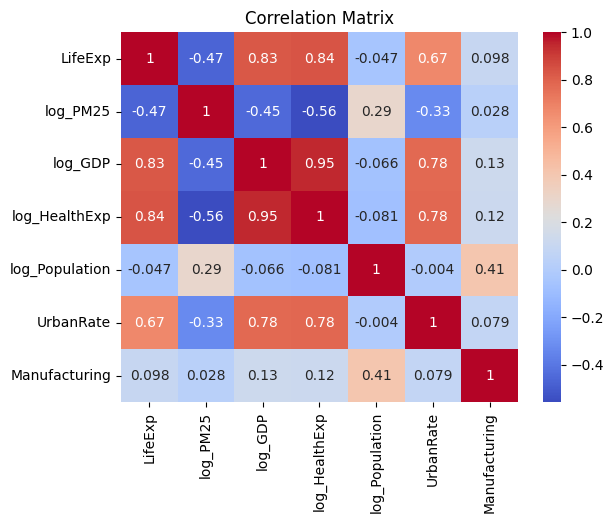

In [57]:
# correlation matrix
corr = df[[
    "LifeExp",
    "log_PM25",
    "log_GDP",
    "log_HealthExp",
    "log_Population",
    "UrbanRate",
    "Manufacturing"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

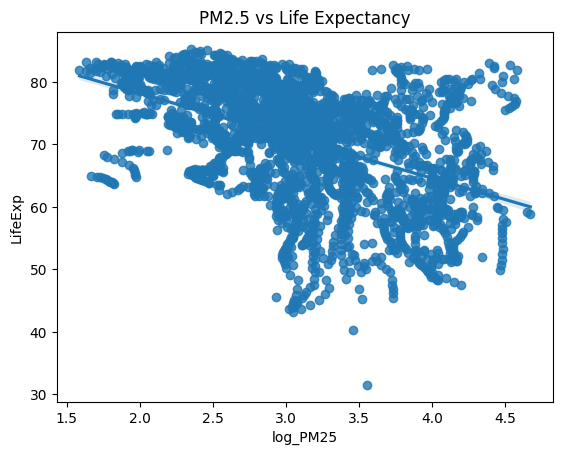

In [59]:
# key plot (main RQ)
sns.regplot(x="log_PM25", y="LifeExp", data=df)
plt.title("PM2.5 vs Life Expectancy")
plt.show()

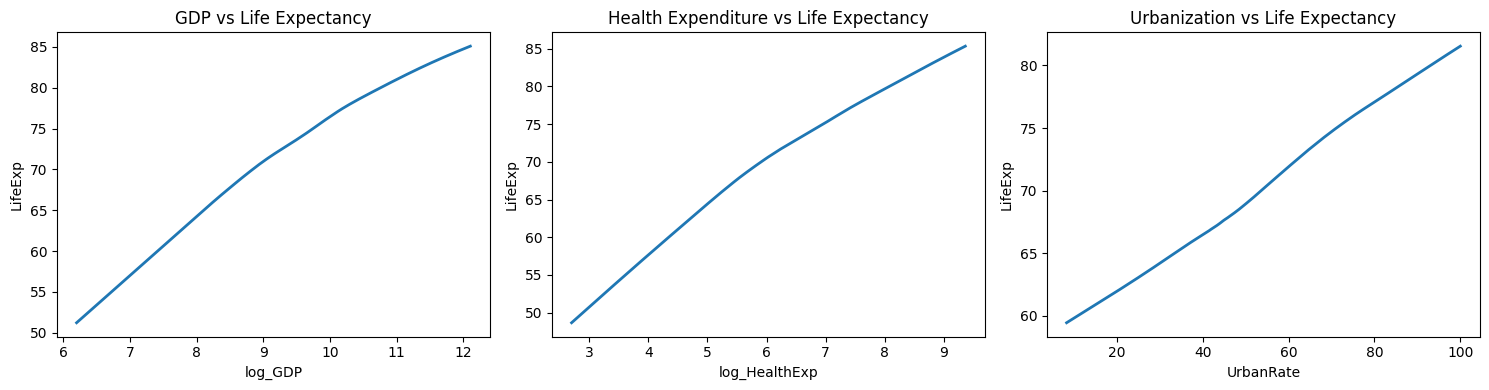

In [60]:
# trendlines for control variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# GDP
sns.regplot(x="log_GDP", y="LifeExp", data=df,
            lowess=True, scatter=False, line_kws={"linewidth": 2}, ax=axes[0])
axes[0].set_title("GDP vs Life Expectancy")

# Urbanization
sns.regplot(x="log_HealthExp", y="LifeExp", data=df,
            lowess=True, scatter=False, line_kws={"linewidth": 2}, ax=axes[1])
axes[1].set_title("Health Expenditure vs Life Expectancy")

# Urbanization
sns.regplot(x="UrbanRate", y="LifeExp", data=df,
            lowess=True, scatter=False, line_kws={"linewidth": 2}, ax=axes[2])
axes[2].set_title("Urbanization vs Life Expectancy")

plt.tight_layout()
plt.show()

In [61]:
# baseline model
X1 = sm.add_constant(df[["log_PM25_lag1"]])
y = df["LifeExp"]

model1 = sm.OLS(y, X1).fit(cov_type="HC1")
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                LifeExp   R-squared:                       0.213
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     760.2
Date:                Tue, 31 Mar 2026   Prob (F-statistic):          2.89e-149
Time:                        19:58:31   Log-Likelihood:                -10374.
No. Observations:                2985   AIC:                         2.075e+04
Df Residuals:                    2983   BIC:                         2.076e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            91.5082      0.723    126.542

In [62]:
# model 2: economic controls
X2 = sm.add_constant(df[["log_PM25_lag1", "log_GDP", "log_HealthExp"]])

model2 = sm.OLS(y, X2).fit(cov_type="HC1")
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                LifeExp   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     3200.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:58:31   Log-Likelihood:                -8872.2
No. Observations:                2985   AIC:                         1.775e+04
Df Residuals:                    2981   BIC:                         1.778e+04
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            28.2396      1.147     24.630

In [63]:
# final complete model
# add year fixed effects
df_fe = pd.get_dummies(df, columns=["Year"], drop_first=True)

X3_columns = [
    "log_PM25_lag1", "log_GDP", "log_HealthExp",
    "log_Population", "UrbanRate", "Manufacturing"
] + [col for col in df_fe.columns if col.startswith("Year_")]

X3 = df_fe[X3_columns]

X3 = X3.astype(float)

X3 = sm.add_constant(X3)
y3 = df_fe["LifeExp"]

model3 = sm.OLS(y3, X3).fit(cov_type="HC1")
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                LifeExp   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     395.3
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:58:31   Log-Likelihood:                -8859.2
No. Observations:                2985   AIC:                         1.777e+04
Df Residuals:                    2959   BIC:                         1.793e+04
Df Model:                          25                                         
Covariance Type:                  HC1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             27.5837      1.467     18.

In [64]:
# income-based heterogeneity
df["HighIncome"] = (df["GDP"] > df["GDP"].median()).astype(int)

df["interaction"] = df["log_PM25_lag1"] * df["HighIncome"]

X_het = sm.add_constant(df[[
    "log_PM25_lag1", "HighIncome", "interaction",
    "log_GDP", "log_HealthExp"
]])

model_het = sm.OLS(y, X_het).fit(cov_type="HC1")
print(model_het.summary())

                            OLS Regression Results                            
Dep. Variable:                LifeExp   R-squared:                       0.714
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     1988.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:58:31   Log-Likelihood:                -8864.9
No. Observations:                2985   AIC:                         1.774e+04
Df Residuals:                    2979   BIC:                         1.778e+04
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            28.4068      1.641     17.311

In [65]:
# lag robustness
df["log_PM25_lag2"] = df.groupby("Country")["log_PM25"].shift(2)
df_lag2 = df.dropna(subset=["log_PM25_lag2"])

X_lag2 = sm.add_constant(df_lag2[["log_PM25_lag2", "log_GDP", "log_HealthExp"]])
y_lag2 = df_lag2["LifeExp"]

model_lag2 = sm.OLS(y_lag2, X_lag2).fit(cov_type="HC1")
print(model_lag2.summary())

                            OLS Regression Results                            
Dep. Variable:                LifeExp   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     2810.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:58:31   Log-Likelihood:                -7864.1
No. Observations:                2661   AIC:                         1.574e+04
Df Residuals:                    2657   BIC:                         1.576e+04
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            27.8906      1.201     23.214

In [67]:
# train-test data split
train = df[df["Year"] <= 2015]
test = df[df["Year"] > 2015]

In [68]:
# fit model to train
X_train = sm.add_constant(train[[
    "log_PM25_lag1", "log_GDP", "log_HealthExp",
    "log_Population", "UrbanRate", "Manufacturing"
]])
y_train = train["LifeExp"]

model_train = sm.OLS(y_train, X_train).fit()

In [70]:
# model testing
X_test = sm.add_constant(test[[
    "log_PM25_lag1", "log_GDP", "log_HealthExp",
    "log_Population", "UrbanRate", "Manufacturing"
]])
y_test = test["LifeExp"]

y_pred = model_train.predict(X_test)

In [71]:
# test evaluation metrics
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test R2:", r2)
print("RMSE:", rmse)

Test R2: 0.7470454393515198
RMSE: 3.953299872109933


In [72]:
# train error
r2_train = model_train.rsquared
print("Train R2:", r2_train)

Train R2: 0.6980537752844824


In [73]:
df.to_excel("final_cleaned_dataset.xlsx", index=False)